# Limpieza y preprocesamiento de datos: BD Residencia

Este notebook documenta el proceso de limpieza, exploración y preparación del
dataset **BD_Residencia**, que contiene registros de turistas extranjeros que
ingresaron a México por vía aérea, clasificados por aeropuerto, país de residencia,
sexo, región y periodo (2012–2026).

El objetivo es obtener dos versiones limpias del dataset:
- **`df_completo`**: dataset íntegro para análisis descriptivo y visualización.
- **`df_modelo`**: subconjunto depurado para el entrenamiento del modelo predictivo
  (excluye años COVID y el año en curso incompleto).

In [ ]:
!pip install openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("Configuración terminada")

Configuración terminada


## 1. Carga del dataset

El dataset se carga directamente desde el repositorio del proyecto en GitHub.
Se verifica el número de filas y columnas obtenidas para confirmar una carga exitosa.

In [ ]:
url = (
    "https://github.com/Montiel-Oscar/ciencia_de_datos_2026_2/"
    "raw/552f465ade9ba3116828cd61d143bca1007a824a/"
    "proyecto_borrador/datasets/BD_Residencia.xlsx"
)

df = pd.read_excel(url, engine="openpyxl")
print(f"Cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head(10)

Cargado: 423,776 filas × 10 columnas


,Año,Fecha,MesNum,Mes,Aeropuerto,Origen,Pais,Región,Sexo,Valor
0,2012,2012/1/01,1,Enero,"Acapulco, Gro.",Residencia,Alemania,Europa,Hombre,1
1,2012,2012/1/01,1,Enero,"Acapulco, Gro.",Residencia,Alemania,Europa,Mujer,1
2,2012,2012/1/01,1,Enero,"Acapulco, Gro.",Residencia,Australia,Oceanía,Hombre,6
3,2012,2012/1/01,1,Enero,"Acapulco, Gro.",Residencia,Australia,Oceanía,Mujer,1
4,2012,2012/1/01,1,Enero,"Acapulco, Gro.",Residencia,Barbados,Islas del Caribe,Hombre,1
5,2012,2012/1/01,1,Enero,"Acapulco, Gro.",Residencia,Brasil,América del Sur,Hombre,3
6,2012,2012/1/01,1,Enero,"Acapulco, Gro.",Residencia,Brasil,América del Sur,Mujer,4
7,2012,2012/1/01,1,Enero,"Acapulco, Gro.",Residencia,Canadá,América del Norte,Hombre,1231
8,2012,2012/1/01,1,Enero,"Acapulco, Gro.",Residencia,Canadá,América del Norte,Mujer,1321
9,2012,2012/1/01,1,Enero,"Acapulco, Gro.",Residencia,Ecuador,América del Sur,Mujer,1


## 2. Exploración general

Se inspeccionan los tipos de dato de cada columna, la presencia de valores nulos
y la cardinalidad (número de valores únicos). Este paso permite identificar los
problemas de calidad que se abordarán en la etapa de limpieza.

In [ ]:
print("=" * 55)
print("FORMA DEL DATASET")
print(f"  Filas:    {df.shape[0]:,}")
print(f"  Columnas: {df.shape[1]}")

print("\nTIPOS DE DATOS Y NULOS")
print("=" * 55)
info = pd.DataFrame({
    'dtype':    df.dtypes,
    'nulos':    df.isnull().sum(),
    '% nulo':   (df.isnull().sum() / len(df) * 100).round(2),
    'únicos':   df.nunique()
})
print(info)

FORMA DEL DATASET
  Filas:    423,776
  Columnas: 10

TIPOS DE DATOS Y NULOS
             dtype  nulos  % nulo  únicos
Año          int64      0     0.0      15
Fecha       object      0     0.0     169
MesNum       int64      0     0.0      12
Mes         object      0     0.0      12
Aeropuerto  object      0     0.0      67
Origen      object      0     0.0       1
Pais        object      0     0.0     245
Región      object      0     0.0       9
Sexo        object      0     0.0       3
Valor        int64      0     0.0    9817


### 2.1 Estadísticas descriptivas

Se obtiene un resumen estadístico de todas las columnas para identificar
rangos, posibles anomalías y la distribución general de los valores numéricos.

In [ ]:
df.describe(include='all')

,Año,Fecha,MesNum,Mes,Aeropuerto,Origen,Pais,Región,Sexo,Valor
count,423776.000000,423776,423776.000000,423776,423776,423776,423776,423776,423776,423776.000000
unique,NaN,169,NaN,12,67,1,245,9,3,NaN
top,NaN,2024/12/01,NaN,Enero,Ciudad de México (AICM),Residencia,Estados Unidos,Europa,Hombre,NaN
freq,NaN,3343,NaN,38796,60666,423776,18767,138796,232877,NaN
mean,2018.637148,NaN,6.493973,NaN,NaN,NaN,NaN,NaN,NaN,524.421864
std,4.166498,NaN,3.537717,NaN,NaN,NaN,NaN,NaN,NaN,6149.642101
min,2012.000000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,2015.000000,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
50%,2018.000000,NaN,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000
75%,2023.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,17.000000


### 2.2 Revisión de variables categóricas y temporales

Se verifican los valores únicos de las columnas clave: años disponibles,
aeropuertos, países de residencia, sexo, región y origen.
Esto permite detectar categorías inconsistentes o de valor único antes de la limpieza.

In [ ]:
print("AÑOS disponibles:", sorted(df['Año'].unique()))
print("\nAEROPUERTOS únicos:", df['Aeropuerto'].nunique())
print(df['Aeropuerto'].value_counts().head(10))
print("\nPAÍSES únicos:", df['Pais'].nunique())
print(df['Pais'].value_counts().head(10))
print("\nSEXO valores:")
print(df['Sexo'].value_counts())
print("\nREGIÓN valores:")
print(df['Región'].value_counts())
print("\nORIGEN valores (debería ser solo 'Residencia'):")
print(df['Origen'].value_counts())

AÑOS disponibles: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

AEROPUERTOS únicos: 67
Aeropuerto
Ciudad de México (AICM)    60666
Cancún, Q. Roo             59535
Guadalajara, Jal.          30422
Puerto Vallarta, Jal.      26373
Monterrey, N.L.            25381
Los Cabos, B.C.S.          23667
Cozumel, Q. Roo            16579
Querétaro, Qro.            14645
Silao, Gto.                14223
Mérida, Yuc.               13218
Name: count, dtype: int64

PAÍSES únicos: 245
Pais
Estados Unidos    18767
Canadá            12020
Reino Unido        8822
Alemania           8338
Francia            7545
España             7461
Australia          7428
Italia             6896
Japón              6885
Brasil             6605
Name: count, dtype: int64

SEXO valores:
Sexo
Hombre           232877
Mujer          

## 3. Limpieza de datos

### 3.1 Eliminación de columnas no informativas

La columna `Origen` contiene un único valor constante ("Residencia") en todos
los registros, por lo que no aporta información al análisis ni al modelo y se elimina.

In [ ]:
cols_antes = df.columns.tolist()

if df['Origen'].nunique() == 1:
    df.drop(columns=['Origen'], inplace=True)
    print("Columna 'Origen' eliminada (valor único)")
else:
    print("'Origen' tiene múltiples valores — revisar manualmente:")
    print(df['Origen'].value_counts())

print(f"\nColumnas antes: {len(cols_antes)}  →  ahora: {df.shape[1]}")
print("Columnas actuales:", df.columns.tolist())

Columna 'Origen' eliminada (valor único)

Columnas antes: 10  →  ahora: 9
Columnas actuales: ['Año', 'Fecha', 'MesNum', 'Mes', 'Aeropuerto', 'Pais', 'Región', 'Sexo', 'Valor']


### 3.2 Corrección de tipos de dato

Se convierten las columnas al tipo adecuado: `Año` y `MesNum` a entero,
`Valor` a numérico (gestionando posibles errores de formato provenientes de Excel),
y `Fecha` a tipo `datetime`.

In [ ]:
df['Año']    = df['Año'].astype(int)
df['MesNum'] = df['MesNum'].astype(int)

df['Valor'] = pd.to_numeric(df['Valor'], errors='coerce')

df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')

print("Tipos de dato corregidos:")
print(df.dtypes)

Tipos de dato corregidos:
Año                    int64
Fecha         datetime64[ns]
MesNum                 int64
Mes                   object
Aeropuerto            object
Pais                  object
Región                object
Sexo                  object
Valor                  int64
dtype: object


### 3.3 Revisión de valores nulos

Se genera un mapa de nulos por columna para cuantificar y localizar
registros incompletos que requieran tratamiento.

In [ ]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
print("Columna         | Nulos | %")
print("-" * 35)
for col in df.columns:
    if nulos[col] > 0:
        print(f"{col:<16} | {nulos[col]:>5} | {nulos_pct[col]}%")

if nulos.sum() == 0:
    print("Sin valores nulos")

Columna         | Nulos | %
-----------------------------------
Sin valores nulos


### 3.4 Tratamiento de registros sin clasificación de género

Se identifican los registros cuya columna `Sexo` contiene el valor
"No disponible". Estos registros carecen también de información de región,
por lo que no pueden ser imputados ni segmentados; se opta por su eliminación
para preservar la integridad del análisis.

In [ ]:
registros_nd = df[df['Sexo'] == 'No disponible']

print(f"Total registros 'No disponible': {len(registros_nd)}")
print("\n¿Son los mismos que 'No especificado' en Región?")
print(df[df['Región'] == 'No especificado']['Sexo'].value_counts())

print("\nDetalle de esos 169 registros:")
print(registros_nd[['Año', 'Mes', 'Aeropuerto', 'Pais', 'Región', 'Sexo', 'Valor']].to_string())

Total registros 'No disponible': 169

¿Son los mismos que 'No especificado' en Región?
Sexo
No disponible    169
Name: count, dtype: int64

Detalle de esos 169 registros:
         Año         Mes       Aeropuerto             Pais           Región           Sexo  Valor
1663    2012       Enero  No especificado  No especificado  No especificado  No disponible   2423
4030    2012     Febrero  No especificado  No especificado  No especificado  No disponible   2432
6411    2012       Marzo  No especificado  No especificado  No especificado  No disponible   3359
8716    2012       Abril  No especificado  No especificado  No especificado  No disponible   2018
10977   2012        Mayo  No especificado  No especificado  No especificado  No disponible   1406
13166   2012       Junio  No especificado  No especificado  No especificado  No disponible   1640
15488   2012       Julio  No especificado  No especificado  No especificado  No disponible   2279
17785   2012      Agosto  No especificado  No

In [ ]:
filas_antes = len(df)

df = df[df['Sexo'] != 'No disponible'].copy()

filas_despues = len(df)
print(f"Registros eliminados: {filas_antes - filas_despues}")
print(f"Filas restantes: {filas_despues:,}")
print(f"\nVerificación Sexo:")
print(df['Sexo'].value_counts())
print(f"\nVerificación Región:")
print(df['Región'].value_counts())

Registros eliminados: 169
Filas restantes: 423,607

Verificación Sexo:
Sexo
Hombre    232877
Mujer     190730
Name: count, dtype: int64

Verificación Región:
Región
Europa               138796
Asia                  92608
América del Sur       47070
África                42482
América del Norte     31920
Islas del Caribe      26936
América Central       22116
Oceanía               21679
Name: count, dtype: int64


### 3.5 Detección de duplicados

Se buscan registros duplicados considerando como clave la combinación de
año, mes, aeropuerto, país y sexo. Un duplicado bajo esta definición
implicaría dos entradas para exactamente el mismo segmento en el mismo periodo.

In [ ]:
clave = ['Año', 'MesNum', 'Aeropuerto', 'Pais', 'Sexo']

duplicados = df[df.duplicated(subset=clave, keep=False)]
print(f"Filas duplicadas en clave {clave}:")
print(f"  Total: {len(duplicados)}")

if len(duplicados) > 0:
    print("\nEjemplos:")
    print(duplicados.sort_values(clave).head(20))
else:
    print("Sin duplicados: cada combinación es única")

Filas duplicadas en clave ['Año', 'MesNum', 'Aeropuerto', 'Pais', 'Sexo']:
  Total: 0
Sin duplicados: cada combinación es única


## 4. Análisis de la variable objetivo

### 4.1 Distribución de la variable `Valor`

Se analiza la distribución del número de turistas por registro,
incluyendo percentiles extremos, para detectar valores atípicos
y entender la dispersión de los datos.

In [ ]:
print("Estadísticas de Valor:")
print(df['Valor'].describe().apply(lambda x: f"{x:,.0f}"))

print(f"\nPercentiles clave:")
percentiles = [90, 95, 99, 99.9]
for p in percentiles:
    val = df['Valor'].quantile(p/100)
    print(f"  P{p:4.1f}: {val:>10,.0f} turistas")

print(f"\nRegistros con Valor > 100,000: {len(df[df['Valor'] > 100_000])}")
print(df[df['Valor'] > 100_000][['Año','Mes','Aeropuerto','Pais','Sexo','Valor']].sort_values('Valor', ascending=False))

Estadísticas de Valor:
count    423,607
mean         524
std        6,151
min            1
25%            1
50%            3
75%           17
max      332,671
Name: Valor, dtype: object

Percentiles clave:
  P90.0:        174 turistas
  P95.0:        846 turistas
  P99.0:      7,156 turistas
  P99.9:     87,661 turistas

Registros con Valor > 100,000: 347
         Año         Mes               Aeropuerto            Pais   Sexo  \
291263  2022       Marzo           Cancún, Q. Roo  Estados Unidos  Mujer   
391262  2025       Marzo           Cancún, Q. Roo  Estados Unidos  Mujer   
274764  2021       Julio           Cancún, Q. Roo  Estados Unidos  Mujer   
300856  2022       Julio           Cancún, Q. Roo  Estados Unidos  Mujer   
298512  2022       Junio           Cancún, Q. Roo  Estados Unidos  Mujer   
...      ...         ...                      ...             ...    ...   
298936  2022       Junio  Ciudad de México (AICM)  Estados Unidos  Mujer   
182203  2017   Diciembre  Ciudad d

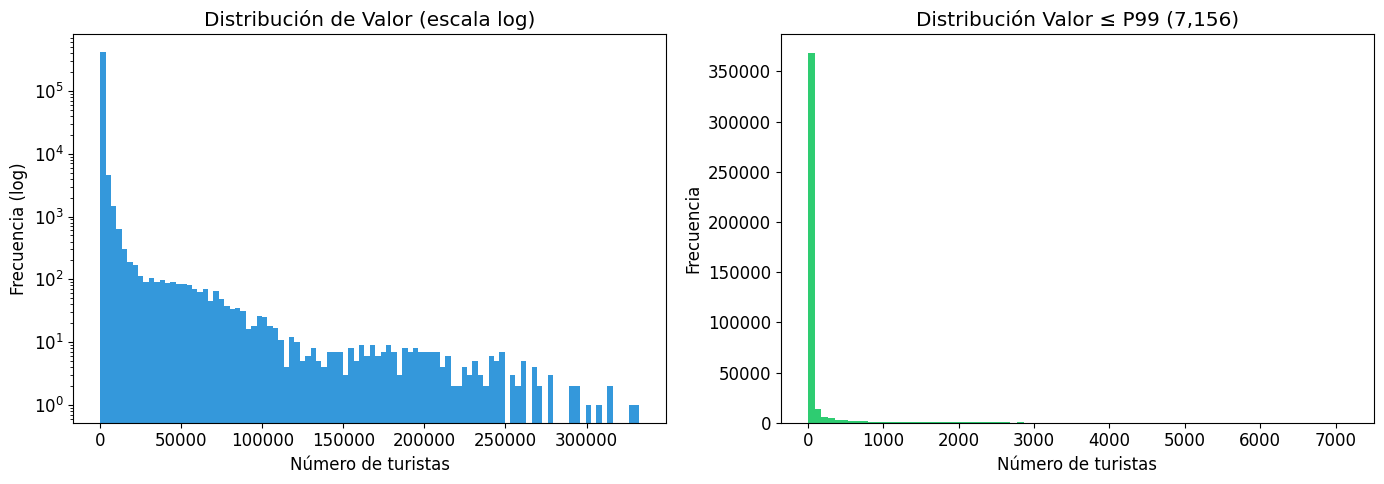

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Valor'], bins=100, color='#3498db', edgecolor='none', log=True)
axes[0].set_title('Distribución de Valor (escala log)')
axes[0].set_xlabel('Número de turistas')
axes[0].set_ylabel('Frecuencia (log)')

p99 = df['Valor'].quantile(0.99)
axes[1].hist(df[df['Valor'] <= p99]['Valor'], bins=80, color='#2ecc71', edgecolor='none')
axes[1].set_title(f'Distribución Valor ≤ P99 ({p99:,.0f})')
axes[1].set_xlabel('Número de turistas')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 5. Análisis temporal

### 5.1 Cobertura del año 2026

Se evalúa qué meses del año 2026 están disponibles en el dataset y
se compara el flujo turístico acumulado en ese mismo periodo contra el año anterior,
con el fin de determinar si el año puede incluirse en el análisis o debe tratarse de forma especial.

In [ ]:
print("Meses disponibles por año (últimos 4 años):")
cobertura = df.groupby(['Año', 'MesNum'])['Valor'].sum().unstack(fill_value=0)
print(cobertura.tail(5).to_string())

print(f"\nTotal turistas 2026 hasta ahora: {df[df['Año']==2026]['Valor'].sum():,.0f}")
print(f"Meses de 2026 disponibles: {sorted(df[df['Año']==2026]['MesNum'].unique())}")

meses_2026 = sorted(df[df['Año']==2026]['MesNum'].unique())
turistas_2025_mismo_periodo = df[
    (df['Año']==2025) & (df['MesNum'].isin(meses_2026))
]['Valor'].sum()
turistas_2026 = df[df['Año']==2026]['Valor'].sum()

print(f"\nMismo periodo 2025: {turistas_2025_mismo_periodo:,.0f}")
print(f"Mismo periodo 2026: {turistas_2026:,.0f}")
print(f"Variación: {((turistas_2026/turistas_2025_mismo_periodo)-1)*100:.1f}%")

Meses disponibles por año (últimos 4 años):
MesNum       1        2        3        4        5        6        7        8        9        10       11       12
Año                                                                                                               
2022    1402923  1525933  1945129  1717918  1617319  1773306  1871607  1502995  1250114  1528482  1746087  2100158
2023    1851131  1755064  1954682  1582136  1428874  1609148  1706434  1322264  1063606  1349649  1632168  2151110
2024    1854233  1928437  2124165  1581097  1597498  1748723  1737673  1353223  1067173  1466620  1770193  2261840
2025    1961368  1926006  2229532  1738249  1498038  1662740  1751651  1309823  1006812  1474679  1758277  2270993
2026    1961490        0        0        0        0        0        0        0        0        0        0        0

Total turistas 2026 hasta ahora: 1,961,490
Meses de 2026 disponibles: [np.int64(1)]

Mismo periodo 2025: 1,961,368
Mismo periodo 2026: 1,961,490
Varia

### 5.2 Impacto de la pandemia COVID-19

Se visualiza la serie histórica de turistas anuales para evidenciar
el efecto de la pandemia en 2020 y 2021, y confirmar la recuperación
del flujo turístico en años posteriores.

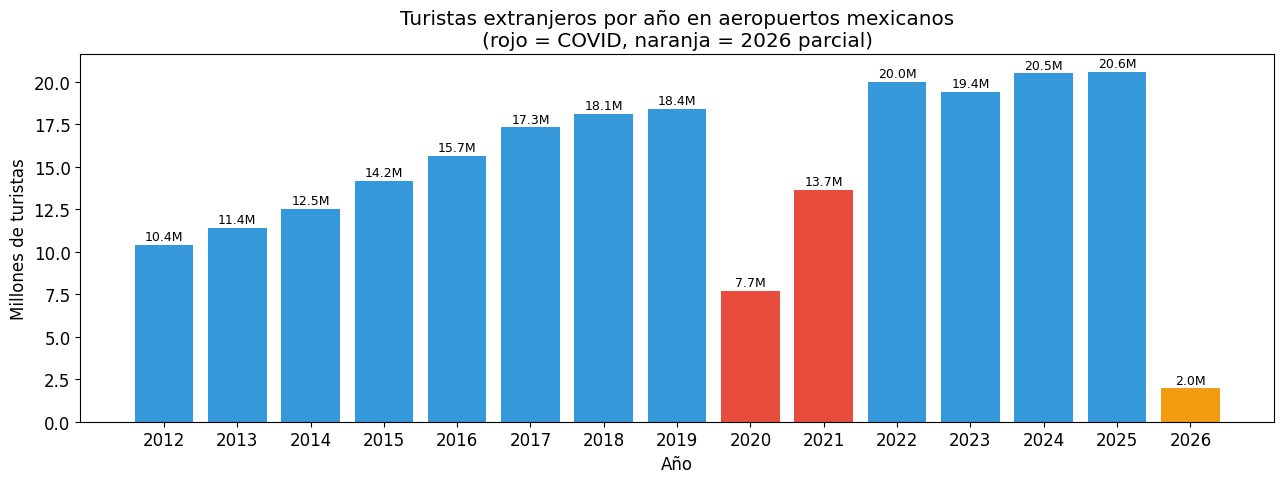

In [ ]:
turistas_año = df.groupby('Año')['Valor'].sum().reset_index()

colores = ['#e74c3c' if a in [2020, 2021] else
           '#f39c12' if a == 2026 else
           '#3498db' for a in turistas_año['Año']]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(turistas_año['Año'], turistas_año['Valor'] / 1e6, color=colores)

for bar, val in zip(bars, turistas_año['Valor']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

ax.set_title('Turistas extranjeros por año en aeropuertos mexicanos\n(rojo = COVID, naranja = 2026 parcial)')
ax.set_ylabel('Millones de turistas')
ax.set_xlabel('Año')
ax.set_xticks(turistas_año['Año'])
plt.tight_layout()
plt.show()

### 5.3 Generación de las dos versiones del dataset

Con base en el análisis temporal se definen dos versiones del dataset:

- **`df_completo`**: incluye todos los años disponibles (2012–2026).
  Se utilizará para análisis descriptivo y visualización de tendencias históricas.
- **`df_modelo`**: excluye los años COVID (2020–2021) y el año en curso incompleto (2026),
  abarcando el periodo 2012–2019 y 2022–2025.
  Se utilizará para el entrenamiento y evaluación del modelo predictivo.

In [ ]:
df_completo = df.copy()

df_modelo = df[~df['Año'].isin([2020, 2021, 2026])].copy()

print(f"Dataset COMPLETO:  {len(df_completo):,} filas  |  {df_completo['Año'].min()}–{df_completo['Año'].max()}")
print(f"Dataset MODELO:    {len(df_modelo):,} filas   |  {df_modelo['Año'].min()}–{df_modelo['Año'].max()}")
print(f"\nAños en dataset modelo: {sorted(df_modelo['Año'].unique())}")

Dataset COMPLETO:  423,607 filas  |  2012–2026
Dataset MODELO:    382,747 filas   |  2012–2025

Años en dataset modelo: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## 6. Validación del dataset

Se realizan verificaciones de sentido de negocio sobre el dataset modelo:
se revisan los aeropuertos y países con mayor volumen histórico,
y se analiza el patrón de estacionalidad mensual para confirmar
que los datos son coherentes con el comportamiento esperado del turismo aéreo en México.

In [ ]:
print("TOP 10 aeropuertos por volumen total:")
top_aeropuertos = (df_modelo.groupby('Aeropuerto')['Valor']
                   .sum().sort_values(ascending=False).head(10))
print(top_aeropuertos.apply(lambda x: f"{x:,.0f}"))

print("\nTOP 10 países de residencia:")
top_paises = (df_modelo.groupby('Pais')['Valor']
              .sum().sort_values(ascending=False).head(10))
print(top_paises.apply(lambda x: f"{x:,.0f}"))

print("\nEstacionalidad promedio (qué meses tienen más turistas):")
estacional = (df_modelo.groupby('Mes')['Valor']
              .sum().reindex(['Enero','Febrero','Marzo','Abril','Mayo',
                              'Junio','Julio','Agosto','Septiembre',
                              'Octubre','Noviembre','Diciembre']))
print(estacional.apply(lambda x: f"{x:,.0f}"))

TOP 10 aeropuertos por volumen total:
Aeropuerto
Cancún, Q. Roo             88,581,551
Ciudad de México (AICM)    41,680,628
Los Cabos, B.C.S.          20,094,250
Puerto Vallarta, Jal.      16,610,677
Guadalajara, Jal.          11,645,285
Monterrey, N.L.             3,129,225
Cozumel, Q. Roo             2,463,343
Silao, Gto.                 2,150,107
Mazatlán, Sin.              1,467,999
Querétaro, Qro.             1,177,983
Name: Valor, dtype: object

TOP 10 países de residencia:
Pais
Estados Unidos    123,620,908
Canadá             23,912,885
Reino Unido         5,672,372
Colombia            5,233,093
Argentina           3,842,391
España              3,248,551
Brasil              3,195,559
Francia             2,630,919
Alemania            2,616,175
Perú                2,059,498
Name: Valor, dtype: object

Estacionalidad promedio (qué meses tienen más turistas):
Mes
Enero         17,671,484
Febrero       17,814,599
Marzo         20,515,402
Abril         16,393,897
Mayo          15,140

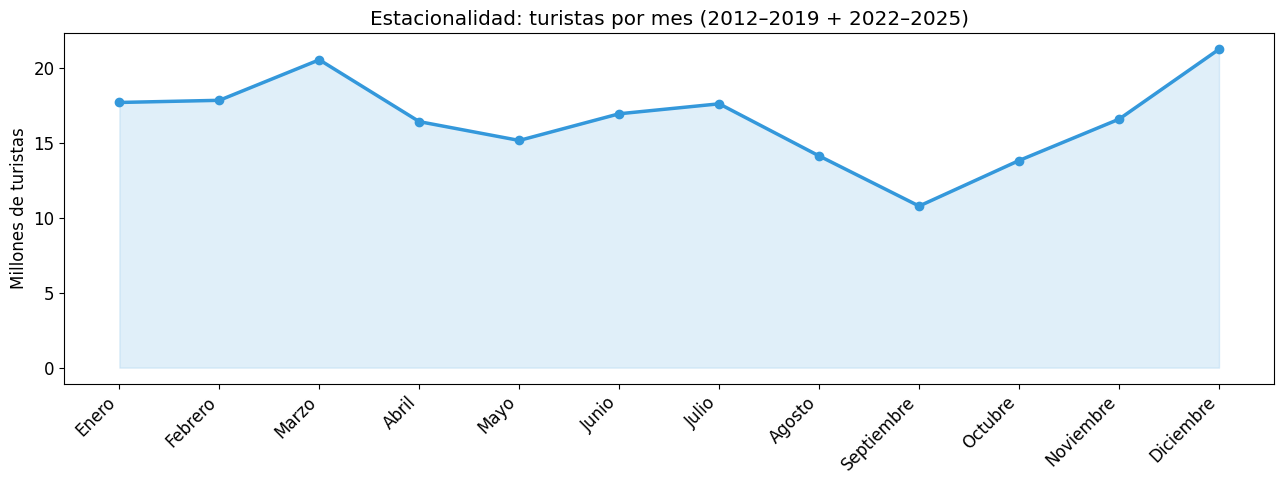

In [ ]:
meses_orden = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
               'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']
estacional_vals = df_modelo.groupby('Mes')['Valor'].sum().reindex(meses_orden)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(meses_orden, estacional_vals / 1e6, marker='o', color='#3498db', linewidth=2.5)
ax.fill_between(range(12), estacional_vals.values / 1e6, alpha=0.15, color='#3498db')
ax.set_xticks(range(12))
ax.set_xticklabels(meses_orden, rotation=45, ha='right')
ax.set_title('Estacionalidad: turistas por mes (2012–2019 + 2022–2025)')
ax.set_ylabel('Millones de turistas')
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 55)
print("REPORTE FINAL — BD_Residencia")
print("=" * 55)
print(f"\n{'DATASET COMPLETO':}")
print(f"  Filas:      {len(df_completo):,}")
print(f"  Nulos:      {df_completo.isnull().sum().sum()}")
print(f"  Años:       {df_completo['Año'].min()}–{df_completo['Año'].max()}")

print(f"\n{'DATASET MODELO (para ML)':}")
print(f"  Filas:      {len(df_modelo):,}")
print(f"  Nulos:      {df_modelo.isnull().sum().sum()}")
print(f"  Años:       {sorted(df_modelo['Año'].unique())}")
print(f"  Aeropuertos:{df_modelo['Aeropuerto'].nunique()}")
print(f"  Países:     {df_modelo['Pais'].nunique()}")
print(f"  Regiones:   {df_modelo['Región'].nunique()}")

print(f"\n{'CAMBIOS APLICADOS':}")
print(f"  Columna 'Origen' eliminada (valor único)")
print(f"  Tipos de dato corregidos (Fecha → datetime, Valor → int)")
print(f"  169 registros sin clasificación de género/región eliminados")
print(f"  Años COVID (2020-2021) excluidos del dataset de modelo")
print(f"  Año 2026 (incompleto) excluido del dataset de modelo")
print(f"  Sin nulos, sin duplicados")

REPORTE FINAL — BD_Residencia

DATASET COMPLETO
  Filas:      423,607
  Nulos:      0
  Años:       2012–2026

DATASET MODELO (para ML)
  Filas:      382,747
  Nulos:      0
  Años:       [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  Aeropuertos:66
  Países:     243
  Regiones:   8

CAMBIOS APLICADOS
  Columna 'Origen' eliminada (valor único)
  Tipos de dato corregidos (Fecha → datetime, Valor → int)
  169 registros sin clasificación de género/región eliminados
  Años COVID (2020-2021) excluidos del dataset de modelo
  Año 2026 (incompleto) excluido del dataset de modelo
  Sin nulos, sin duplicados


## 7. Ajuste final de columnas

Se eliminan del dataset modelo las columnas `Fecha` y `Mes`,
ya que la información temporal queda representada de forma precisa y
parseable por las columnas numéricas `Año` y `MesNum`.
Reducir la dimensionalidad textual redundante mejora la eficiencia del pipeline de modelado.

In [ ]:
cols_antes = df_modelo.columns.tolist()

df_modelo = df_modelo.drop(columns=['Fecha', 'Mes'])

print(f"Columnas eliminadas: Fecha, Mes")
print(f"Columnas antes: {cols_antes}")
print(f"Columnas finales: {df_modelo.columns.tolist()}")
print(f"\nEstructura final del dataset modelo (primeras 5 filas):")
print(df_modelo.head(5))

Columnas eliminadas: Fecha, Mes
Columnas antes: ['Año', 'Fecha', 'MesNum', 'Mes', 'Aeropuerto', 'Pais', 'Región', 'Sexo', 'Valor']
Columnas finales: ['Año', 'MesNum', 'Aeropuerto', 'Pais', 'Región', 'Sexo', 'Valor']

Estructura final del dataset modelo:
    Año  MesNum      Aeropuerto       Pais   Región    Sexo  Valor
0  2012       1  Acapulco, Gro.   Alemania   Europa  Hombre      1
1  2012       1  Acapulco, Gro.   Alemania   Europa   Mujer      1
2  2012       1  Acapulco, Gro.  Australia  Oceanía  Hombre      6


### 7.1 Normalización de variables categóricas

Las columnas de texto (`Aeropuerto`, `Pais`, `Región`, `Sexo`) se normalizan
aplicando tres transformaciones: conversión a minúsculas, eliminación de
acentos mediante normalización Unicode (NFKD) y supresión de espacios
en blanco innecesarios. Esto garantiza consistencia en los valores
categóricos de cara al modelado.

In [ ]:
columnas_texto = ['Aeropuerto', 'Pais', 'Región', 'Sexo']

for col in columnas_texto:
    df_modelo[col] = df_modelo[col].str.lower()

    df_modelo[col] = df_modelo[col].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

    df_modelo[col] = df_modelo[col].str.strip()

print("Texto normalizado con éxito. Muestra de los datos:")
print(df_modelo.head())

Texto normalizado con éxito. Muestra de los datos:
    Año  MesNum      Aeropuerto       Pais            Región    Sexo  Valor
0  2012       1  acapulco, gro.   alemania            europa  hombre      1
1  2012       1  acapulco, gro.   alemania            europa   mujer      1
2  2012       1  acapulco, gro.  australia           oceania  hombre      6
3  2012       1  acapulco, gro.  australia           oceania   mujer      1
4  2012       1  acapulco, gro.   barbados  islas del caribe  hombre      1


## 8. Exportación del dataset limpio

El dataset modelo, ya limpio y normalizado, se exporta en formato CSV
para su uso en las etapas posteriores de modelado y evaluación.

In [ ]:
df_modelo.to_csv('BD_Residencia_modelo.csv', index=False)

from google.colab import files
files.download('BD_Residencia_modelo.csv')
print("Descargados ")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descargados 
